# Homework 3

## Your Name Here (or your names here if you are pair programming)

 - Student Name: Leia Nayana Das
 - Student UT EID: lnd749


 - Partner Name: Javier Diaz de Sandi
 - Partner UT EID: jd52288

## Normal and t distributions
## t-test


An experiment was conducted to determine the effect of children participating in a given meal preparation on calorie intake for that meal. Data are recorded below. 

Save the data to a format that can be read into python. Read the data in for analysis. Data is provided in two separted CSV files. 

* Use python to calculate the quantities and generate the visual summaries requested below. You will lose points if you are not utilizing python.

* You can use scipy libary or other libraries to do your tests or you can implement them from scratch in python 



In [1]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Question - 1
Summarize the data by whether children participated in the meal preparation or not. Use an appropriately labelled table to show the results. Also include a graphical presentation that shows the distribution of calories for participants vs. non-participants. Describe the shape of each distribution and comment on the similarity (or lack thereof) between the distributions in each population. **(2 points)**

Be aware that there is not one specific way the graph needs to look. Experiment with different types of graphs, and different parameters for the graph type. Your goal is to present the data as readable as possible. 

,nonparticipants,participants
25%,296.4,298.4
50%,374.7,424.9
75%,445.6,456.3
count,22.0,25.0
max,688.8,635.2
mean,374.1,410.1
min,139.7,211.0
std,133.1,121.5


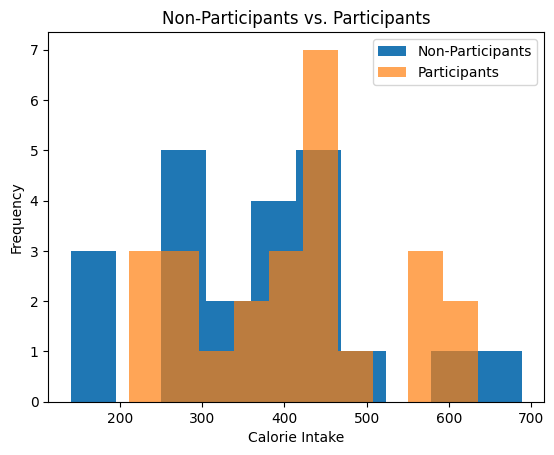

Analysis: 
The distribution of the Non-Participants is more right-skewed, while the distribution of the participants is most similar to a normal distribution.
The mean and minimum values for nonparticipants were much lower than those for participants, which is reflected in the skewness of the data.
The distributions are closer in value at the lower end of calorie intakes, but the difference between them increases as calorie intake increases.


In [61]:
# table to show results
# graphic showing distribution of calories for participants vs. non-participants

nonparticipants = pd.read_csv("nonparticipants.csv")
participants = pd.read_csv("participants.csv")

nonparticipantsSummary = nonparticipants.describe()
participantsSummary = participants.describe()

summaryTable = pd.merge(nonparticipantsSummary, participantsSummary, left_index=True, right_index=True, how="outer").round(decimals=1)

display(summaryTable)

bins = 10
plt.hist(nonparticipants, bins=bins, label="Non-Participants")
plt.hist(participants, bins=bins, alpha=0.7, label="Participants")
plt.title('Non-Participants vs. Participants')
plt.legend()
plt.xlabel('Calorie Intake')
plt.ylabel('Frequency')
plt.show()

print("Analysis: ")
print("The distribution of the Non-Participants is more right-skewed, while the distribution of the participants is most similar to a normal distribution.",
      "The mean and minimum values for nonparticipants were much lower than those for participants, which is reflected in the skewness of the data.",  
      "The distributions are closer in value at the lower end of calorie intakes, but the difference between them increases as calorie intake increases.", sep='\n')


# Question - 2 

Does the mean calorie consumption for those who participated in the meal preparation differ from **425**? Formally test at the $\alpha = 0.05$ level using the 5 steps outlined in the module. **(6 points)**


In [71]:
from scipy import stats

print("1) Set up hypothesis and select alpha level")
print("  -> H0: mu = 425 | the mean calorie consumption for participants is 425")
print("  -> H1: mu != 425 | the mean calorie consumption for participants is not 425")
print("  -> alpha = 0.05")
mu = 425
alpha = 0.05

print()
print("2) Select the appropriate test statistic")
print("  -> Testing with two-sided one-sample t-test")

print()
print("3) State the decision rule")
print("     Find critical value t_crit")
df = len(participants) - 1
#    t.ppf finds the t-statistic with the specified area TO THE LEFT -> parameter should be 1-(alpha/2) ; alpha/2 bc two-sided, 1-() bc area to the left
t_crit = stats.t.ppf(1-alpha/2, df)
print("         t_crit =", t_crit)
print("  -> Decision Rule: Reject H0 if |t| >= %.3f, otherwise, do not reject H0" % t_crit)


print()
print("4) Compute the test statistic and the associated p-value")
test = stats.ttest_1samp(participants, mu)
t_test = test[0][0]
p_value = test[1][0]
print("  -> t_test = %.3f" % t_test)
print("  -> p_value = %.3f" % p_value)

print()
print("5) Conclusion")
if abs(t_test) >= t_crit:
    print("  -> %.3f >= %.3f" % (abs(t_test), t_crit))
    print("  -> |t_test| >= t_crit")
    print('  -> We reject the null hypothesis that the mean calorie consumption for those who participated in the meal preparation is 425, \
          in favor of the alternate hypothesis that the mean calorie consumption for those who participated in the meal preparation differs from 425.')
    print('  -> We have significant evidence at the alpha = 0.05 level that the mean calorie consumption for those who participated in the meal preparation differs from 425.')

elif abs(t_test) < t_crit:
    print("  -> %.3f < %.3f" % (abs(t_test), t_crit))
    print("  -> |t_test| < t_crit")
    print('  -> We fail to reject reject the null hypothesis that the mean calorie consumption for those who participated in the meal preparation is 425.')
    print('  -> We do not have significant evidence at the alpha = 0.05 level that the mean calorie consumption for those who participated in the meal preparation differs from 425.')
print("  -> p value associated with the test statistic of %.3f is %.3f" % (t_test, p_value))





1) Set up hypothesis and select alpha level
  -> H0: mu = 425 | the mean calorie consumption for participants is 425
  -> H1: mu != 425 | the mean calorie consumption for participants is not 425
  -> alpha = 0.05

2) Select the appropriate test statistic
  -> Testing with two-sided one-sample t-test

3) State the decision rule
     Find critical value t_crit
         t_crit = 2.0638985616280205
  -> Decision Rule: Reject H0 if |t| >= 2.064, otherwise, do not reject H0

4) Compute the test statistic and the associated p-value
  -> t_test = -0.614
  -> p_value = 0.545

5) Conclusion
  -> 0.614 < 2.064
  -> |t_test| < t_crit
  -> We fail to reject reject the null hypothesis that the mean calorie consumption for those who participated in the meal preparation is 425.
  -> We do not have significant evidence at the alpha = 0.05 level that the mean calorie consumption for those who participated in the meal preparation differs from 425.
  -> p value associated with the test statistic of -0.614

# Question -3 
Calculate a **90%** confidence interval for the mean calorie intake for participants in the meal preparation. Interpret the confidence interval. **(6 points)**

In [73]:

n = df + 1
mean = participants['participants'].mean()
std = participants['participants'].std(ddof=1)
se = std / np.sqrt(n)
t_critical = stats.t.ppf(1 - 0.05, df=df)  

ci_lower = mean - t_critical * se
ci_upper = mean + t_critical * se

print(f"90% confidence interval for the mean calorie intake: ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"Interpretation: We are 90% confident that the true mean calorie intake among participants is between {ci_lower:.2f} and {ci_upper:.2f} calories.")

90% confidence interval for the mean calorie intake: (368.50, 451.66)
Interpretation: We are 90% confident that the true mean calorie intake among participants is between 368.50 and 451.66 calories.


# Question 4 
Formally test whether or not participants consumed 
more calories than non-participants at the $\alpha = 0.05$ level using the 5 steps procedure for hypothesis tests. **(6 points )**

In [85]:
# mu1 participants, mu2 non-participants

print("1) Set up hypothesis and select alpha level")
print("  -> H0: mu1 - mu2 = 0 | Participants and non-participants consumed the same amount of calories.")
print("  -> H1: mu1 > mu2     | Participants consumed more calories than non-participants.")
print("  -> alpha = 0.05")
alpha = 0.05

print()
print("2) Select the appropriate test statistic")
print("  -> Testing with one-sided two-sample t-test")

print()
print("3) State the decision rule")
print("  -> Decision Rule: Reject H0 if p_value <= alpha, otherwise, do not reject H0")

print()
print("4) Compute the test statistic and the associated p-value")
test = stats.ttest_ind(participants, nonparticipants, alternative="greater")
t_test = test[0][0]
p_value = test[1][0]
print("  -> t_test = %.3f" % t_test)
print("  -> p_value = %.3f" % p_value)

print()
print("5) Conclusion")
if p_value <= alpha:
    print("  -> %.3f <= %.3f" % (p_value, alpha))
    print("  -> p_value <= alpha")
    print('  -> We reject the null hypothesis that participants and non-participants consumed the same amount of calories, \
          in favor of the alternative hypothesis that participants consumed more calories than non-participants.')
    print('  -> We have significant evidence at the alpha = 0.05 level that participants consumed more calories than non-participants.')

elif p_value > alpha:
    print("  -> %.3f > %.3f" % (p_value, alpha))
    print("  -> p_value > alpha")
    print('  -> We fail to reject the null hypothesis that participants and non-participants consumed the same amount of calories.')
    print('  -> We do not have significant evidence at the alpha = 0.05 level that participants consumed more calories than non-participants.')
print("  -> p value associated with the test statistic of %.3f is %.3f" % (t_test, p_value))




1) Set up hypothesis and select alpha level
  -> H0: mu1 - mu2 = 0 | Participants and non-participants consumed the same amount of calories.
  -> H1: mu1 > mu2     | Participants consumed more calories than non-participants.
  -> alpha = 0.05

2) Select the appropriate test statistic
  -> Testing with one-sided two-sample t-test

3) State the decision rule
  -> Decision Rule: Reject H0 if p_value <= alpha, otherwise, do not reject H0

4) Compute the test statistic and the associated p-value
  -> t_test = 0.969
  -> p_value = 0.169

5) Conclusion
  -> 0.169 > 0.050
  -> p_value > alpha
  -> We fail to reject the null hypothesis that participants and non-participants consumed the same amount of calories.
  -> We do not have significant evidence at the alpha = 0.05 level that participants consumed more calories than non-participants.
  -> p value associated with the test statistic of 0.969 is 0.169
